# CS242 Part B1 — BERT + FAISS Dense Indexing



### What this notebook produces:
- `indexes/faiss/faiss.index` — FAISS IndexFlatIP
- `indexes/faiss/embeddings.npy` — raw BERT embeddings (numpy)
- `indexes/faiss/passage_meta.json` — all metadata per passage
- `indexes/faiss/passage_ids.json` — ordered passage ID list
- `indexes/faiss/index_stats.json` — runtime + config
- `data/derived/passages.jsonl` — passage_id → doc_id mapping
- `data/derived/passages_with_embeddings.jsonl` — passages + BERT embeddings
- `results/bert_runtime.csv` — benchmark at 1k/2k/5k/9k docs
- `results/bert_vs_lucene_runtime.png` — comparison plot

In [1]:
# ── Cell 1: Check GPU ─────────────────────────────────────────────────
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Using device: cuda


In [2]:
# ── Cell 2: Mount Google Drive ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/CS242_PartB'
os.makedirs(OUTPUT_DIR + '/indexes/faiss', exist_ok=True)
os.makedirs(OUTPUT_DIR + '/data/derived', exist_ok=True)
os.makedirs(OUTPUT_DIR + '/results', exist_ok=True)
print('Output directory ready:', OUTPUT_DIR)

Mounted at /content/drive
Output directory ready: /content/drive/MyDrive/CS242_PartB


In [3]:
# ── Cell 3: Install dependencies ──────────────────────────────────────
!pip install faiss-cpu torch transformers numpy matplotlib --quiet
!pip install tqdm boto3 requests regex sentencepiece sacremoses --quiet
print('All dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.4 MB/s eta 0:00:00
All dependencies installed


In [4]:
# ── Cell 4: Set input path ────────────────────────────────────────────
# Upload newdocs.jsonl to Google Drive first, then set path below
INPUT_JSONL = '/content/drive/MyDrive/CS242_PartB/newdocs.jsonl'
print('Input:', INPUT_JSONL)
print('Exists:', os.path.exists(INPUT_JSONL))

import os
if os.path.exists(INPUT_JSONL):
    size_mb = os.path.getsize(INPUT_JSONL) / 1e6
    print(f'File size: {size_mb:.1f} MB')

Input: /content/drive/MyDrive/CS242_PartB/newdocs.jsonl
Exists: True
File size: 1172.2 MB


In [5]:
# ── Cell 5: Preview newdocs.jsonl ─────────────────────────────────────
import json

print('Sample documents from newdocs.jsonl:')
print('='*60)
with open(INPUT_JSONL, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        obj = json.loads(line)
        print(f'\n--- Doc {i+1} ---')
        print(f'doc_id:     {obj.get("doc_id")}')
        print(f'title:      {obj.get("title")}')
        print(f'authors:    {str(obj.get("authors"))[:80]}')
        print(f'conference: {obj.get("conference")}')
        print(f'year:       {obj.get("year")}')
        print(f'url:        {obj.get("url")}')
        print(f'abstract:   {str(obj.get("abstract",""))[:150]}...')
        print(f'body len:   {len(obj.get("body",""))} chars')
        print(f'categories: {obj.get("categories")}')
        if i >= 2:
            break

Sample documents from newdocs.jsonl:

--- Doc 1 ---
doc_id:     jNQ40aw5qL
title:      Amortized Active Generation of Pareto Sets
authors:    Daniel M. Steinberg, Asiri Wijesinghe, Rafael Oliveira, Piotr Koniusz, Cheng Soo
conference: NeurIPS
year:       2025
url:        https://openreview.net/forum?id=jNQ40aw5qL
abstract:   We introduce active generation of Pareto sets (A-GPS), a new framework for online discrete black-box multi-objective optimization (MOO). A-GPS learns ...
body len:   24760 chars
categories: []

--- Doc 2 ---
doc_id:     rJ5ky9C3ue
title:      CrossSpectra: Exploiting Cross-Layer Smoothness for Parameter-Efficient Fine-Tuning
authors:    Yifei Zhang, Hao Zhu, Junhao Dong, Haoran Shi, Ziqiao Meng, Piotr Koniusz, Han Y
conference: NeurIPS
year:       2025
url:        https://openreview.net/forum?id=rJ5ky9C3ue
abstract:   Parameter-efficient fine-tuning (PEFT) is essential for adapting large foundation models without excessive storage cost. However, current approaches 

In [7]:
# ── Cell 6: Load BERT ─────────────────────────────────────────────────
import torch
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = 'allenai/specter'
MAX_TOKENS = 512

print(f'Loading {MODEL_NAME}...')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

print(f'Model loaded on {DEVICE}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')


Loading allenai/specter...


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: allenai/specter
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on cuda
Parameters: 109,938,432


In [8]:
# ── Cell 7: Helper functions ──────────────────────────────────────────
import json
import numpy as np
import time

def build_text(obj):
    """
    Text to embed: title + [SEP] + abstract
    Standard DPR/BEIR practice for academic papers.
    Fits in 512 tokens — no splitting needed for most papers.
    """
    title    = (obj.get('title') or '').strip()
    abstract = (obj.get('abstract') or '').strip()
    if title and abstract:
        return f'{title} [SEP] {abstract}'
    return title or abstract


def split_into_passages(text, tokenizer, max_tokens=510, stride=64):
    """
    Sliding window passage splitter.
    window = 510 tokens (reserves 2 for [CLS] and [SEP])
    stride = 64 tokens overlap for context continuity
    Used only when text exceeds 512 tokens (rare for title+abstract).
    """
    if not text or not text.strip():
        return []
    tokens = tokenizer.encode(text, add_special_tokens=False)
    if not tokens:
        return []
    # If fits in one passage — return directly
    if len(tokens) <= max_tokens:
        return [text.strip()]
    # Sliding window split
    step     = max_tokens - stride
    passages = []
    start    = 0
    while start < len(tokens):
        end   = min(start + max_tokens, len(tokens))
        chunk = tokenizer.decode(tokens[start:end])
        if len(chunk.strip()) >= 20:
            passages.append(chunk.strip())
        if end >= len(tokens):
            break
        start += step
    return passages


def embed_batch(texts, tokenizer, model, batch_size=32):
    """
    Embed list of texts using BERT [CLS] token.
    Returns L2-normalized float32 numpy array (N, 768).
    """
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch   = texts[i:i+batch_size]
        encoded = tokenizer(
            batch, padding=True, truncation=True,
            max_length=MAX_TOKENS, return_tensors='pt'
        )
        ids   = encoded['input_ids'].to(DEVICE)
        mask  = encoded['attention_mask'].to(DEVICE)
        ttype = encoded.get('token_type_ids')
        if ttype is not None:
            ttype = ttype.to(DEVICE)
        with torch.no_grad():
            out = model(ids, attention_mask=mask, token_type_ids=ttype)
            cls = out[0][:, 0, :]   # [CLS] token
            cls = torch.nn.functional.normalize(cls, p=2, dim=1)
        all_embs.append(cls.cpu().numpy().astype('float32'))
    return np.vstack(all_embs)


def iter_jsonl(path, max_docs=None):
    n = 0
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if max_docs and n >= max_docs:
                break
            line = line.strip()
            if not line:
                continue
            try:
                yield json.loads(line)
                n += 1
            except:
                continue

print('Helper functions ready')

Helper functions ready


In [9]:
# ── Cell 8: Read all passages from newdocs.jsonl ──────────────────────
BATCH_SIZE  = 32   # larger batch on GPU
MAX_DOCS    = 9000 # covers full dataset of 8,924 papers

print(f'Reading passages from {INPUT_JSONL}...')
all_texts = []  # text to embed
all_meta  = []  # metadata for each passage
n_docs    = 0

for obj in iter_jsonl(INPUT_JSONL, max_docs=MAX_DOCS):
    doc_id = obj.get('doc_id', f'doc_{n_docs}')
    text   = build_text(obj)

    # Split into passages (≤512 BERT tokens)
    chunks = split_into_passages(text, tokenizer)
    if not chunks:
        chunks = [text[:2000]] if text else []

    for i, chunk in enumerate(chunks):
        pid = f'{doc_id}__p{i}'
        all_texts.append(chunk)
        all_meta.append({
            'passage_id':  pid,
            'doc_id':      doc_id,
            'title':       (obj.get('title') or '').strip(),
            'abstract':    (obj.get('abstract') or '').strip(),
            'authors':     (obj.get('authors') or '').strip(),
            'conference':  (obj.get('conference') or '').strip(),
            'year':        obj.get('year'),
            'url':         (obj.get('url') or '').strip(),
            'categories':  obj.get('categories', []),
            'text':        chunk,
            'passage_idx': i,
        })

    n_docs += 1
    if n_docs % 1000 == 0:
        print(f'  {n_docs} docs → {len(all_texts)} passages')

print(f'\nTotal: {n_docs} docs → {len(all_texts)} passages')
print(f'Avg passages per doc: {len(all_texts)/n_docs:.2f}')

Reading passages from /content/drive/MyDrive/CS242_PartB/newdocs.jsonl...
  1000 docs → 1709 passages
  2000 docs → 3260 passages
  3000 docs → 5049 passages
  4000 docs → 7226 passages
  5000 docs → 9248 passages
  6000 docs → 11102 passages
  7000 docs → 14436 passages
  8000 docs → 18063 passages

Total: 8924 docs → 21382 passages
Avg passages per doc: 2.40


In [10]:
# ── Cell 8: Read all passages from newdocs.jsonl ──────────────────────
import json, time

BATCH_SIZE = 32
MAX_DOCS   = 9000

# Step 1: Deduplicate + filter junk
seen_ids   = set()
clean_docs = []

with open(INPUT_JSONL, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            obj = json.loads(line)
        except:
            continue
        did      = (obj.get('doc_id') or '').strip()
        abstract = (obj.get('abstract') or '').strip()
        title    = (obj.get('title') or '').strip()
        if not did or did in seen_ids:
            continue
        if len(abstract) < 50 or len(title) < 3:
            continue
        seen_ids.add(did)
        clean_docs.append(obj)
        if len(clean_docs) >= MAX_DOCS:
            break

print(f'Clean unique docs: {len(clean_docs)}')

# Step 2: Build passages
all_texts = []
all_meta  = []

for obj in clean_docs:
    doc_id = obj.get('doc_id', '')
    text   = build_text(obj)
    chunks = split_into_passages(text, tokenizer)
    if not chunks:
        chunks = [text[:2000]] if text else []
    for i, chunk in enumerate(chunks):
        all_texts.append(chunk)
        all_meta.append({
            'passage_id':  f'{doc_id}__p{i}',
            'doc_id':      doc_id,
            'title':       (obj.get('title') or '').strip(),
            'abstract':    (obj.get('abstract') or '').strip(),
            'authors':     (obj.get('authors') or '').strip(),
            'conference':  (obj.get('conference') or '').strip(),
            'year':        obj.get('year', ''),
            'url':         (obj.get('url') or '').strip(),
            'categories':  obj.get('categories', []),
            'text':        chunk,
            'passage_idx': i,
        })

print(f'Total passages: {len(all_texts):,}')
print(f'Avg per doc:    {len(all_texts)/len(clean_docs):.1f}')
print(f'Sample title:   {all_meta[0]["title"]}')

Clean unique docs: 8734
Total passages: 21,193
Avg per doc:    2.4
Sample title:   Amortized Active Generation of Pareto Sets


In [11]:
# ── Cell 9: Runtime benchmark (1k, 2k, 5k, 9k docs) ──────────────────
# Matches Lucene benchmark checkpoints for fair comparison
import csv
import faiss

CHECKPOINTS = [1000, 2000, 5000, 9000]
benchmark_rows = []

print(f'{"Docs":>8} {"Passages":>10} {"Encode(s)":>12} {"FAISS(s)":>10} {"Total(s)":>10} {"Pass/sec":>10}')
print('-' * 65)

for n_docs_ckpt in CHECKPOINTS:
    n_pass = min(n_docs_ckpt, len(all_texts))
    texts  = all_texts[:n_pass]

    # Time BERT embedding
    t0       = time.time()
    embs     = embed_batch(texts, tokenizer, model, BATCH_SIZE)
    encode_s = time.time() - t0

    # Time FAISS index build
    t1      = time.time()
    idx     = faiss.IndexFlatIP(768)
    idx.add(embs)
    faiss_s = time.time() - t1
    total_s = encode_s + faiss_s

    benchmark_rows.append({
        'n_docs':     n_docs_ckpt,
        'n_passages': n_pass,
        'encode_s':   round(encode_s, 2),
        'faiss_s':    round(faiss_s, 4),
        'total_s':    round(total_s, 2),
        'pass_per_sec': round(n_pass/encode_s, 2),
    })
    print(f'{n_docs_ckpt:>8} {n_pass:>10} {encode_s:>12.2f} '
          f'{faiss_s:>10.4f} {total_s:>10.2f} {n_pass/encode_s:>10.2f}')

# Save bert_runtime.csv
csv_path = OUTPUT_DIR + '/results/bert_runtime.csv'
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=[
        'n_docs','n_passages','encode_s','faiss_s','total_s','pass_per_sec'])
    w.writeheader()
    w.writerows(benchmark_rows)
print(f'\nSaved: {csv_path}')

    Docs   Passages    Encode(s)   FAISS(s)   Total(s)   Pass/sec
-----------------------------------------------------------------
    1000       1000        35.89     0.0079      35.89      27.87
    2000       2000        75.69     0.0018      75.70      26.42
    5000       5000       188.41     0.0122     188.42      26.54
    9000       9000       343.98     0.0094     343.99      26.16

Saved: /content/drive/MyDrive/CS242_PartB/results/bert_runtime.csv


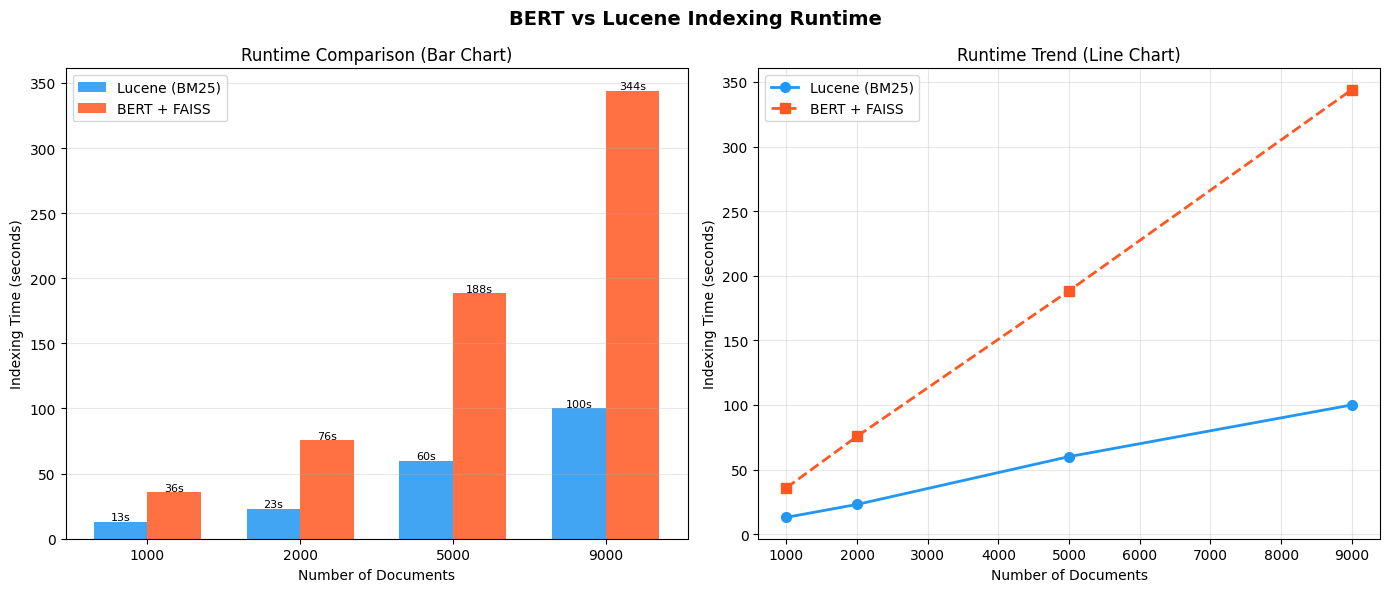

Saved: /content/drive/MyDrive/CS242_PartB/results/bert_vs_lucene_runtime.png


In [12]:
# ── Cell 10: Generate runtime comparison plot ─────────────────────────
import matplotlib.pyplot as plt

# Lucene runtimes from Part A report
lucene_docs  = [1000, 2000, 5000, 9000]
lucene_times = [13,   23,   60,   100]

bert_docs  = [r['n_docs']  for r in benchmark_rows]
bert_times = [r['total_s'] for r in benchmark_rows]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('BERT vs Lucene Indexing Runtime',
             fontsize=14, fontweight='bold')

# Bar chart
x     = range(len(bert_docs))
width = 0.35
b1 = ax1.bar([i-width/2 for i in x], lucene_times, width,
             label='Lucene (BM25)', color='#2196F3', alpha=0.85)
b2 = ax1.bar([i+width/2 for i in x], bert_times, width,
             label='BERT + FAISS', color='#FF5722', alpha=0.85)
ax1.set_xlabel('Number of Documents')
ax1.set_ylabel('Indexing Time (seconds)')
ax1.set_title('Runtime Comparison (Bar Chart)')
ax1.set_xticks(list(x))
ax1.set_xticklabels([str(d) for d in bert_docs])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
for b in b1:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+1,
             f'{b.get_height():.0f}s', ha='center', fontsize=8)
for b in b2:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+1,
             f'{b.get_height():.0f}s', ha='center', fontsize=8)

# Line chart
ax2.plot(lucene_docs, lucene_times, 'o-', color='#2196F3',
         lw=2, ms=7, label='Lucene (BM25)')
ax2.plot(bert_docs, bert_times, 's--', color='#FF5722',
         lw=2, ms=7, label='BERT + FAISS')
ax2.set_xlabel('Number of Documents')
ax2.set_ylabel('Indexing Time (seconds)')
ax2.set_title('Runtime Trend (Line Chart)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plot_path = OUTPUT_DIR + '/results/bert_vs_lucene_runtime.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {plot_path}')

In [13]:
# ── Cell 11: Build FINAL full index
print(f'Embedding all {len(all_texts)} passages...')
t0   = time.time()
embs = embed_batch(all_texts, tokenizer, model, BATCH_SIZE)
t_encode = time.time() - t0

print(f'Building FAISS index...')
t1          = time.time()
final_index = faiss.IndexFlatIP(768)
final_index.add(embs)
t_faiss     = time.time() - t1

print(f'\nEncode time: {t_encode:.2f}s')
print(f'FAISS time:  {t_faiss:.4f}s')
print(f'Total time:  {t_encode+t_faiss:.2f}s')
print(f'Speed:       {len(all_texts)/t_encode:.2f} passages/sec')
print(f'Index size:  {final_index.ntotal} vectors x 768 dims')

Embedding all 21193 passages...
Building FAISS index...

Encode time: 821.50s
FAISS time:  0.0446s
Total time:  821.55s
Speed:       25.80 passages/sec
Index size:  21193 vectors x 768 dims


In [14]:
# ── Cell 12: Save ALL outputs to Google Drive ─────────────────────────
import os

# 1. faiss.index
faiss_path = OUTPUT_DIR + '/indexes/faiss/faiss.index'
faiss.write_index(final_index, faiss_path)
print(f'faiss.index              → {os.path.getsize(faiss_path)/1e6:.1f} MB')

# 2. embeddings.npy — raw BERT embeddings
emb_path = OUTPUT_DIR + '/indexes/faiss/embeddings.npy'
np.save(emb_path, embs)
print(f'embeddings.npy           → {os.path.getsize(emb_path)/1e6:.1f} MB')

# 3. passage_meta.json — all metadata
meta_path = OUTPUT_DIR + '/indexes/faiss/passage_meta.json'
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump({
        m['passage_id']: {k: m[k] for k in (
            'doc_id','title','abstract','authors',
            'conference','year','url','categories',
            'text','passage_idx'
        )} for m in all_meta
    }, f, ensure_ascii=False)
print(f'passage_meta.json        → {os.path.getsize(meta_path)/1e6:.1f} MB')

# 4. passage_ids.json — ordered list
ids_path = OUTPUT_DIR + '/indexes/faiss/passage_ids.json'
with open(ids_path, 'w') as f:
    json.dump([m['passage_id'] for m in all_meta], f)
print(f'passage_ids.json         → {os.path.getsize(ids_path)/1e6:.2f} MB')

# 5. passages.jsonl — passage_id → doc_id mapping
pass_path = OUTPUT_DIR + '/data/derived/passages.jsonl'
with open(pass_path, 'w', encoding='utf-8') as f:
    for m in all_meta:
        f.write(json.dumps({
            'passage_id':  m['passage_id'],
            'doc_id':      m['doc_id'],
            'title':       m['title'],
            'text':        m['text'],
            'passage_idx': m['passage_idx'],
        }, ensure_ascii=False) + '\n')
print(f'passages.jsonl           → {os.path.getsize(pass_path)/1e6:.1f} MB')

# 6. index_meta.json — required by search_dense.py
meta2_path = OUTPUT_DIR + '/indexes/faiss/index_meta.json'
with open(meta2_path, 'w') as f:
    json.dump({
        'model'       : MODEL_NAME,
        'dim'         : 768,
        'num_passages': len(all_texts),
        'num_docs'    : len(all_meta),
        'max_tokens'  : MAX_TOKENS,
    }, f, indent=2)
print(f'index_meta.json          → saved')


faiss.index              → 65.1 MB
embeddings.npy           → 65.1 MB
passage_meta.json        → 872.5 MB
passage_ids.json         → 1.49 MB
passages.jsonl           → 44.2 MB
index_meta.json          → saved


In [22]:
# ── Cell 13: Test search ──────────────────────────────────────────────
def test_search(query, index, all_meta_list, k=5):
    encoded = tokenizer(
        [query], padding=True, truncation=True,
        max_length=MAX_TOKENS, return_tensors='pt'
    )
    ids  = encoded['input_ids'].to(DEVICE)
    mask = encoded['attention_mask'].to(DEVICE)
    with torch.no_grad():
        out = model(ids, attention_mask=mask)
        cls = out[0][:, 0, :]
        cls = torch.nn.functional.normalize(cls, p=2, dim=1)
    qvec = cls.cpu().numpy().astype('float32')

    scores, indices = index.search(qvec, k*10)

    print(f'\nQuery: "{query}"')
    print('='*70)
    seen = set()
    rank = 1
    for score, idx in zip(scores[0], indices[0]):
        m = all_meta_list[idx]
        if m['doc_id'] in seen:
            continue
        seen.add(m['doc_id'])
        print(f'[{rank}] Score={score:.4f} | {m["conference"]} {m["year"]}')
        print(f'     Title:   {m["title"]}')
        print(f'     Authors: {str(m["authors"])[:80]}')
        if m.get('url'):
            print(f'     URL:     {m["url"]}')
        if m.get('abstract'):                              # ← ADD
            print(f'     Snippet: {m["abstract"][:200]}') # ← ADD
        rank += 1
        if rank > k:
            break

test_search('attention mechanism transformer', final_index, all_meta)
test_search('autonomous driving perception', final_index, all_meta)
test_search('federated learning privacy', final_index, all_meta)
test_search('Climate', final_index, all_meta)
test_search('neural science', final_index, all_meta)
test_search('Large Language model', final_index, all_meta)
test_search('Information Retrieval', final_index, all_meta)
test_search('Graph neural network', final_index, all_meta)
test_search('Deep learning', final_index, all_meta)


Query: "attention mechanism transformer"
[1] Score=0.8484 |  None
     Title:   g Attention Sinks: A ‘Catch, Tag, Release’ Mechanism for Embeddings
     Authors: Stephen Zhang, Mustafa Khan, Vardan Papyan
     Snippet: Large language models (LLMs) often concentrate their attention on a few specific
tokens referred to as attention sinks . Common examples include the first token, a
prompt-independent sink, and punctua
[2] Score=0.8437 |  None
     Title:   Don’t Just Chase “Highlighted Tokens” in MLLMs: Revisiting Visual Holistic Context Retention
     Authors: Xin Zou , Di Lu , Yizhou Wang , Yibo Yan , Yuanhuiyi Lyu ,
     Snippet: Despite their powerful capabilities, Multimodal Large Language Models (MLLMs)
suffer from considerable computational overhead due to their reliance on massive
visual tokens. Recent studies have explor
[3] Score=0.8412 | NeurIPS 2025
     Title:   What are you sinking? A geometric approach on attention sink
     Authors: Valeria Ruscio, Umberto Nanni, Fabrizi